# 02 — Download historical RDU actual observations

This notebook downloads **historical surface observations measured at Raleigh-Durham International Airport (RDU)** for the weather forecasting project.

### Source
We use NOAA/NCEI's **Global Historical Climatology Network-hourly (GHCNh)**, NOAA's current hourly/synoptic station dataset.

- RDU GHCNh station ID: `USW00013722`
- Station: Raleigh-Durham International Airport
- NOAA GHCNh landing page:  
  https://www.ncei.noaa.gov/products/global-historical-climatology-network-hourly
- NOAA direct-download pattern used here:  
  `https://www.ncei.noaa.gov/oa/global-historical-climatology-network/hourly/access/by-year/<YEAR>/psv/GHCNh_<STATION>_<YEAR>.psv`

### Project rule enforced here
The assignment cutoff is **September 17, 2026 at 12:00 AM America/New_York**.

This notebook **strictly removes every observation at or after that cutoff**, so the Sept. 17–30 target period cannot leak into training data.

### Output
The final modeling-friendly file is:

`../data/raw/RDU_ACTUAL_HISTORICAL.csv`

It contains one selected RDU observation per clock hour where an observation exists. We preserve the original observation timestamp and do **not** interpolate missing temperatures in this notebook.

> If NOAA download access fails, do not silently switch to another source. The failed NOAA URL will be printed. Download that exact file manually into `../data/raw/ghcnh_cache/` and rerun, or send the error back for help.

In [1]:
from pathlib import Path
from io import StringIO
import re
import time

import numpy as np
import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

In [2]:
# -----------------------------
# Project paths and constants
# -----------------------------

RAW_DIR = Path("../data/raw")
CACHE_DIR = RAW_DIR / "ghcnh_cache"

RAW_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

STATION_ID = "USW00013722"
STATION_LABEL = "Raleigh-Durham International Airport"

LOCAL_TZ = "America/New_York"

# Long historical window for climatology / lag features / model training.
START_LOCAL = pd.Timestamp("2016-01-01 00:00:00", tz=LOCAL_TZ)

# IMPORTANT: assignment cutoff. No observation at or after this instant is allowed.
CUTOFF_LOCAL = pd.Timestamp("2026-09-17 00:00:00", tz=LOCAL_TZ)

START_UTC = START_LOCAL.tz_convert("UTC")
CUTOFF_UTC = CUTOFF_LOCAL.tz_convert("UTC")

YEARS = list(range(START_LOCAL.year, CUTOFF_LOCAL.year + 1))

OUTPUT_FILE = RAW_DIR / "RDU_ACTUAL_HISTORICAL.csv"

NOAA_BASE = (
    "https://www.ncei.noaa.gov/oa/"
    "global-historical-climatology-network/hourly/access/by-year"
)

print("Station:", STATION_ID, "-", STATION_LABEL)
print("Start local:", START_LOCAL)
print("Cutoff local:", CUTOFF_LOCAL)
print("Start UTC:", START_UTC)
print("Cutoff UTC:", CUTOFF_UTC)
print("Years:", YEARS)
print("Output:", OUTPUT_FILE)

Station: USW00013722 - Raleigh-Durham International Airport
Start local: 2016-01-01 00:00:00-05:00
Cutoff local: 2026-09-17 00:00:00-04:00
Start UTC: 2016-01-01 05:00:00+00:00
Cutoff UTC: 2026-09-17 04:00:00+00:00
Years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Output: ../data/raw/RDU_ACTUAL_HISTORICAL.csv


## Download the official NOAA GHCNh station-year files

NOAA provides one pipe-separated (`.psv`) file per station per year.

The code below:
1. Downloads each RDU station-year file directly from NOAA.
2. Caches it in `data/raw/ghcnh_cache/` so rerunning the notebook does not redownload everything.
3. Retries temporary HTTP failures.
4. Raises a clear error rather than silently falling back to another data source.

In [3]:
def noaa_url(year: int) -> str:
    return (
        f"{NOAA_BASE}/{year}/psv/"
        f"GHCNh_{STATION_ID}_{year}.psv"
    )


def make_session() -> requests.Session:
    session = requests.Session()

    retry = Retry(
        total=4,
        connect=4,
        read=4,
        backoff_factor=1.5,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=("GET",),
    )

    session.mount("https://", HTTPAdapter(max_retries=retry))

    # Descriptive user agent for a small academic download.
    session.headers.update({
        "User-Agent": "Duke-AIPI520-RDU-weather-project/1.0"
    })

    return session


def download_year(year: int, session: requests.Session, force=False) -> Path:
    url = noaa_url(year)
    local_path = CACHE_DIR / f"GHCNh_{STATION_ID}_{year}.psv"

    if local_path.exists() and local_path.stat().st_size > 0 and not force:
        print(f"{year}: using cached file -> {local_path.name}")
        return local_path

    print(f"{year}: downloading")
    print("   ", url)

    try:
        response = session.get(url, timeout=90)
        response.raise_for_status()
    except Exception as e:
        raise RuntimeError(
            f"\nNOAA download failed for {year}.\n"
            f"URL: {url}\n\n"
            "Do NOT silently replace this with a different weather source.\n"
            "Try opening the URL in your browser. If it downloads, save the file as:\n"
            f"{local_path}\n"
            "Then rerun this notebook.\n\n"
            f"Original error: {e}"
        ) from e

    # Basic guard against an HTML error page being saved as data.
    head = response.content[:500].lower()
    if b"<html" in head or b"<!doctype" in head:
        raise RuntimeError(
            f"NOAA returned HTML instead of a PSV data file for {year}.\n"
            f"URL: {url}"
        )

    local_path.write_bytes(response.content)

    if local_path.stat().st_size == 0:
        raise RuntimeError(f"Downloaded file is empty: {local_path}")

    print(f"    saved {local_path.stat().st_size / 1_000_000:.2f} MB")

    # Be polite to the NOAA server.
    time.sleep(0.25)

    return local_path

In [4]:
session = make_session()

year_files = []

for year in YEARS:
    path = download_year(year, session=session, force=False)
    year_files.append(path)

print(f"\nDownloaded/found {len(year_files)} annual files.")

2016: downloading
    https://www.ncei.noaa.gov/oa/global-historical-climatology-network/hourly/access/by-year/2016/psv/GHCNh_USW00013722_2016.psv
    saved 10.92 MB
2017: downloading
    https://www.ncei.noaa.gov/oa/global-historical-climatology-network/hourly/access/by-year/2017/psv/GHCNh_USW00013722_2017.psv
    saved 10.83 MB
2018: downloading
    https://www.ncei.noaa.gov/oa/global-historical-climatology-network/hourly/access/by-year/2018/psv/GHCNh_USW00013722_2018.psv
    saved 11.10 MB
2019: downloading
    https://www.ncei.noaa.gov/oa/global-historical-climatology-network/hourly/access/by-year/2019/psv/GHCNh_USW00013722_2019.psv
    saved 10.91 MB
2020: downloading
    https://www.ncei.noaa.gov/oa/global-historical-climatology-network/hourly/access/by-year/2020/psv/GHCNh_USW00013722_2020.psv
    saved 11.16 MB
2021: downloading
    https://www.ncei.noaa.gov/oa/global-historical-climatology-network/hourly/access/by-year/2021/psv/GHCNh_USW00013722_2021.psv
    saved 10.85 MB
2022

## Load and combine the NOAA files

GHCNh files can contain more than one report within an hour. For example, airport weather stations can issue special reports when conditions change.

We first retain the underlying observations. Later, for each clock hour, we select the valid temperature observation most representative of RDU's routine late-hour airport report.

In [5]:
def normalize_column_name(name: str) -> str:
    name = str(name).strip().lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    return name.strip("_")


annual_frames = []

for path in year_files:
    df_year = pd.read_csv(
        path,
        sep="|",
        low_memory=False
    )

    df_year.columns = [normalize_column_name(c) for c in df_year.columns]

    print(
        path.name,
        "->",
        f"{len(df_year):,} rows,",
        f"{len(df_year.columns)} columns"
    )

    annual_frames.append(df_year)

ghcnh = pd.concat(annual_frames, ignore_index=True)

print("\nCombined shape:", ghcnh.shape)
print("\nFirst 30 normalized column names:")
print(ghcnh.columns[:30].tolist())

GHCNh_USW00013722_2016.psv -> 11,406 rows, 329 columns
GHCNh_USW00013722_2017.psv -> 11,248 rows, 329 columns
GHCNh_USW00013722_2018.psv -> 11,495 rows, 329 columns
GHCNh_USW00013722_2019.psv -> 11,414 rows, 329 columns
GHCNh_USW00013722_2020.psv -> 11,585 rows, 329 columns
GHCNh_USW00013722_2021.psv -> 11,414 rows, 329 columns
GHCNh_USW00013722_2022.psv -> 11,417 rows, 329 columns
GHCNh_USW00013722_2023.psv -> 11,698 rows, 329 columns
GHCNh_USW00013722_2024.psv -> 13,006 rows, 329 columns
GHCNh_USW00013722_2025.psv -> 12,785 rows, 329 columns
GHCNh_USW00013722_2026.psv -> 66,132 rows, 329 columns

Combined shape: (183600, 329)

First 30 normalized column names:
['station', 'station_name', 'date', 'year', 'month', 'day', 'hour', 'minute', 'latitude', 'longitude', 'elevation', 'temperature', 'temperature_measurement_code', 'temperature_quality_code', 'temperature_report_type', 'temperature_source_code', 'temperature_source_station_id', 'dew_point_temperature', 'dew_point_temperature_mea

In [6]:
# -----------------------------
# Build UTC observation time
# -----------------------------

required_time_columns = ["year", "month", "day", "hour", "minute"]

missing_time_columns = [
    c for c in required_time_columns
    if c not in ghcnh.columns
]

if missing_time_columns:
    raise KeyError(
        "Expected GHCNh time columns were not found: "
        f"{missing_time_columns}\n"
        f"Columns present: {ghcnh.columns.tolist()}"
    )

for col in required_time_columns:
    ghcnh[col] = pd.to_numeric(ghcnh[col], errors="coerce")

ghcnh["observation_time_utc"] = pd.to_datetime(
    {
        "year": ghcnh["year"],
        "month": ghcnh["month"],
        "day": ghcnh["day"],
        "hour": ghcnh["hour"],
        "minute": ghcnh["minute"],
    },
    errors="coerce",
    utc=True,
)

ghcnh = ghcnh.dropna(subset=["observation_time_utc"]).copy()

# Hard project-boundary filter:
ghcnh = ghcnh[
    (ghcnh["observation_time_utc"] >= START_UTC)
    & (ghcnh["observation_time_utc"] < CUTOFF_UTC)
].copy()

ghcnh = ghcnh.sort_values("observation_time_utc").reset_index(drop=True)

print("Rows after date filtering:", f"{len(ghcnh):,}")
print("Earliest observation:", ghcnh["observation_time_utc"].min())
print("Latest observation:", ghcnh["observation_time_utc"].max())

assert (ghcnh["observation_time_utc"] < CUTOFF_UTC).all()

/tmp/ipykernel_46909/930337748.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ghcnh["observation_time_utc"] = pd.to_datetime(


Rows after date filtering: 181,682
Earliest observation: 2016-01-01 05:51:00+00:00
Latest observation: 2026-09-17 03:55:00+00:00


## Inspect temperature and choose one observation per hour

GHCNh's core `temperature` field is dry-bulb air temperature in **°C**.

RDU's routine METAR observation is normally transmitted near the end of the hour. Rather than averaging routine reports together with off-hour special reports, the selection logic below:

1. Prefers a row with a non-missing temperature.
2. Prefers observations from minute 45–59.
3. Within that window, prefers the report closest to minute 51.
4. Keeps the exact original observation timestamp for transparency.

No missing hour is fabricated or interpolated here.

In [7]:
if "temperature" not in ghcnh.columns:
    raise KeyError(
        "NOAA GHCNh file does not contain the expected 'temperature' column.\n"
        f"Columns present: {ghcnh.columns.tolist()}"
    )

ghcnh["temperature"] = pd.to_numeric(
    ghcnh["temperature"],
    errors="coerce"
)

print(ghcnh["temperature"].describe())
print(
    "\nTemperature non-null rate:",
    f"{ghcnh['temperature'].notna().mean():.2%}"
)

# A broad physical sanity check only. This does not modify the data.
suspicious_temp = ghcnh[
    ghcnh["temperature"].notna()
    & ~ghcnh["temperature"].between(-60, 60)
]

print("Temperatures outside [-60, 60] °C:", len(suspicious_temp))

count    125690.000000
mean         16.925135
std           9.185246
min         -15.600000
25%          10.000000
50%          18.300000
75%          23.900000
max          40.000000
Name: temperature, dtype: float64

Temperature non-null rate: 69.18%
Temperatures outside [-60, 60] °C: 0


In [8]:
# Label each clock hour in UTC.
ghcnh["hour_utc"] = ghcnh["observation_time_utc"].dt.floor("h")

# Selection preferences.
ghcnh["_temp_missing"] = ghcnh["temperature"].isna().astype(int)
ghcnh["_late_hour"] = ghcnh["minute"].between(45, 59).astype(int)
ghcnh["_distance_from_51"] = (ghcnh["minute"] - 51).abs()

# Sort so the best candidate for each hour appears first.
candidate_sort = ghcnh.sort_values(
    by=[
        "hour_utc",
        "_temp_missing",       # non-missing temperature first
        "_late_hour",          # late-hour observations first
        "_distance_from_51",   # closest to :51
        "observation_time_utc"
    ],
    ascending=[
        True,
        True,
        False,
        True,
        True
    ]
)

hourly = (
    candidate_sort
    .drop_duplicates(subset=["hour_utc"], keep="first")
    .sort_values("hour_utc")
    .reset_index(drop=True)
)

hourly = hourly.drop(
    columns=[
        "_temp_missing",
        "_late_hour",
        "_distance_from_51"
    ],
    errors="ignore"
)

print("Selected hourly rows:", f"{len(hourly):,}")
print(
    "Selected rows with temperature:",
    f"{hourly['temperature'].notna().sum():,}"
)

hourly[
    [
        "observation_time_utc",
        "hour_utc",
        "minute",
        "temperature"
    ]
].tail(10)

Selected hourly rows: 93,769
Selected rows with temperature: 93,737


,observation_time_utc,hour_utc,minute,temperature
93759,2026-09-16 18:51:00+00:00,2026-09-16 18:00:00+00:00,51,28.9
93760,2026-09-16 19:51:00+00:00,2026-09-16 19:00:00+00:00,51,30.0
93761,2026-09-16 20:51:00+00:00,2026-09-16 20:00:00+00:00,51,30.0
93762,2026-09-16 21:51:00+00:00,2026-09-16 21:00:00+00:00,51,29.4
93763,2026-09-16 22:51:00+00:00,2026-09-16 22:00:00+00:00,51,28.3
93764,2026-09-16 23:51:00+00:00,2026-09-16 23:00:00+00:00,51,25.6
93765,2026-09-17 00:51:00+00:00,2026-09-17 00:00:00+00:00,51,24.4
93766,2026-09-17 01:51:00+00:00,2026-09-17 01:00:00+00:00,51,22.2
93767,2026-09-17 02:51:00+00:00,2026-09-17 02:00:00+00:00,51,21.7
93768,2026-09-17 03:51:00+00:00,2026-09-17 03:00:00+00:00,51,21.1


## Build a clean modeling-friendly table

We keep the original NOAA observation plus useful historical weather variables when they are available. These can later be used for lagged / recent-condition features, but only when they occur before a historical forecast origin.

Native GHCNh units used below:
- temperature / dew point: °C
- relative humidity: %
- wind speed / gust: m/s
- pressure: hPa
- visibility: km
- precipitation: mm

We also add Fahrenheit temperature because the project will likely be easiest to interpret in °F.

In [9]:
def numeric_series(df, column):
    if column not in df.columns:
        return pd.Series(np.nan, index=df.index, dtype=float)

    return pd.to_numeric(df[column], errors="coerce")


def value_series(df, *candidate_columns):
    for column in candidate_columns:
        if column in df.columns:
            return df[column]

    return pd.Series(pd.NA, index=df.index, dtype="object")


out = pd.DataFrame(index=hourly.index)

out["station_id"] = value_series(hourly, "station_id")
out["station_name"] = value_series(hourly, "station_name")

out["observation_time_utc"] = hourly["observation_time_utc"]
out["hour_utc"] = hourly["hour_utc"]

out["observation_time_local"] = (
    hourly["observation_time_utc"]
    .dt.tz_convert(LOCAL_TZ)
)
out["hour_local"] = (
    hourly["hour_utc"]
    .dt.tz_convert(LOCAL_TZ)
)

# Main target variable.
out["temperature_c"] = numeric_series(hourly, "temperature")
out["temperature_f"] = out["temperature_c"] * 9 / 5 + 32

# Other observed weather variables that may be useful later.
out["dew_point_c"] = numeric_series(
    hourly,
    "dew_point_temperature"
)
out["dew_point_f"] = out["dew_point_c"] * 9 / 5 + 32

out["relative_humidity_pct"] = numeric_series(
    hourly,
    "relative_humidity"
)

out["wind_direction_deg"] = numeric_series(
    hourly,
    "wind_direction"
)

out["wind_speed_mps"] = numeric_series(
    hourly,
    "wind_speed"
)

out["wind_gust_mps"] = numeric_series(
    hourly,
    "wind_gust"
)

out["sea_level_pressure_hpa"] = numeric_series(
    hourly,
    "sea_level_pressure"
)

out["station_level_pressure_hpa"] = numeric_series(
    hourly,
    "station_level_pressure"
)

out["altimeter_hpa"] = numeric_series(
    hourly,
    "altimeter"
)

out["visibility_km"] = numeric_series(
    hourly,
    "visibility"
)

out["precipitation_mm"] = numeric_series(
    hourly,
    "precipitation"
)

# Cloud / categorical fields. GHCNh versions can expose slightly
# different names, so we preserve whichever common field exists.
out["sky_cover_1"] = value_series(
    hourly,
    "sky_cover_1",
    "sky_cover_layer_1",
    "sky_cover_summation_1"
)
out["sky_cover_2"] = value_series(
    hourly,
    "sky_cover_2",
    "sky_cover_layer_2",
    "sky_cover_summation_2"
)
out["sky_cover_3"] = value_series(
    hourly,
    "sky_cover_3",
    "sky_cover_layer_3",
    "sky_cover_summation_3"
)

out["latitude"] = numeric_series(hourly, "latitude")
out["longitude"] = numeric_series(hourly, "longitude")
out["elevation_m"] = numeric_series(hourly, "elevation")

# Preserve useful provenance / QC fields if NOAA supplies them.
out["temperature_quality_code"] = value_series(
    hourly,
    "temperature_quality_code"
)
out["temperature_report_type"] = value_series(
    hourly,
    "temperature_report_type"
)
out["temperature_source_code"] = value_series(
    hourly,
    "temperature_source_code"
)
out["temperature_source_station_id"] = value_series(
    hourly,
    "temperature_source_station_id"
)

out["source"] = "NOAA NCEI GHCNh"

out.head()

,station_id,station_name,observation_time_utc,hour_utc,observation_time_local,hour_local,temperature_c,temperature_f,dew_point_c,dew_point_f,...,sky_cover_2,sky_cover_3,latitude,longitude,elevation_m,temperature_quality_code,temperature_report_type,temperature_source_code,temperature_source_station_id,source
0,<NA>,RALEIGH AP,2016-01-01 05:51:00+00:00,2016-01-01 05:00:00+00:00,2016-01-01 00:51:00-05:00,2016-01-01 00:00:00-05:00,10.0,50.00,6.1,42.98,...,NaN,NaN,35.8922,-78.7819,120.4,5.0,FM15,343.0,723060-13722,NOAA NCEI GHCNh
1,<NA>,RALEIGH AP,2016-01-01 06:51:00+00:00,2016-01-01 06:00:00+00:00,2016-01-01 01:51:00-05:00,2016-01-01 01:00:00-05:00,9.4,48.92,5.6,42.08,...,NaN,NaN,35.8922,-78.7819,120.4,5.0,FM15,343.0,723060-13722,NOAA NCEI GHCNh
2,<NA>,RALEIGH AP,2016-01-01 07:51:00+00:00,2016-01-01 07:00:00+00:00,2016-01-01 02:51:00-05:00,2016-01-01 02:00:00-05:00,8.9,48.02,4.4,39.92,...,NaN,NaN,35.8922,-78.7819,120.4,5.0,FM15,343.0,723060-13722,NOAA NCEI GHCNh
3,<NA>,RALEIGH AP,2016-01-01 08:51:00+00:00,2016-01-01 08:00:00+00:00,2016-01-01 03:51:00-05:00,2016-01-01 03:00:00-05:00,8.3,46.94,3.9,39.02,...,NaN,NaN,35.8922,-78.7819,120.4,5.0,FM15,343.0,723060-13722,NOAA NCEI GHCNh
4,<NA>,RALEIGH AP,2016-01-01 09:51:00+00:00,2016-01-01 09:00:00+00:00,2016-01-01 04:51:00-05:00,2016-01-01 04:00:00-05:00,8.3,46.94,3.3,37.94,...,NaN,NaN,35.8922,-78.7819,120.4,5.0,FM15,343.0,723060-13722,NOAA NCEI GHCNh


## Quality checks before saving

These checks are intentionally strict. If the current-year NOAA archive has not yet reached the project cutoff, the notebook stops rather than pretending the data are complete.

In [10]:
# -----------------------------
# Coverage checks
# -----------------------------

expected_hours = pd.date_range(
    start=START_UTC.floor("h"),
    end=CUTOFF_UTC.floor("h"),
    freq="h",
    inclusive="left"
)

actual_temp_hours = pd.DatetimeIndex(
    out.loc[out["temperature_f"].notna(), "hour_utc"].unique()
).sort_values()

missing_temp_hours = expected_hours.difference(actual_temp_hours)

coverage = 1 - len(missing_temp_hours) / len(expected_hours)

print("Expected clock hours:", f"{len(expected_hours):,}")
print("Hours with selected temperature:", f"{len(actual_temp_hours):,}")
print("Missing temperature hours:", f"{len(missing_temp_hours):,}")
print("Temperature coverage:", f"{coverage:.3%}")

print("\nEarliest saved hour:", out["hour_utc"].min())
print("Latest saved hour:", out["hour_utc"].max())

print("\nMedian coordinates:")
print("latitude :", out["latitude"].median())
print("longitude:", out["longitude"].median())

print("\nMissingness (%):")
display(
    (
        out.isna().mean()
        .mul(100)
        .sort_values(ascending=False)
        .round(2)
        .to_frame("missing_pct")
    )
)

# Absolute leakage guard.
assert (out["observation_time_utc"] < CUTOFF_UTC).all(), (
    "LEAKAGE DETECTED: observations at/after the assignment cutoff exist."
)

# Make sure the dataset reaches the final pre-cutoff local hour.
last_required_local_hour = CUTOFF_LOCAL - pd.Timedelta(hours=1)
last_required_utc_hour = last_required_local_hour.tz_convert("UTC").floor("h")

if actual_temp_hours.empty or actual_temp_hours.max() < last_required_utc_hour:
    raise RuntimeError(
        "\nSTOP: NOAA GHCNh did not provide temperature observations "
        "through the final pre-cutoff hour.\n"
        f"Required through: {last_required_local_hour} local "
        f"({last_required_utc_hour} UTC)\n"
        f"Latest available temperature hour: "
        f"{actual_temp_hours.max() if len(actual_temp_hours) else 'NONE'}\n\n"
        "Do not silently substitute a different source. "
        "Send this output back so we can decide the next step."
    )

print("\nPASS: data reaches the final pre-cutoff hour.")
print("PASS: no observation at/after the assignment cutoff is present.")

if len(missing_temp_hours) > 0:
    print("\nFirst 20 missing temperature hours:")
    print(missing_temp_hours[:20])

Expected clock hours: 93,887
Hours with selected temperature: 93,737
Missing temperature hours: 150
Temperature coverage: 99.840%

Earliest saved hour: 2016-01-01 05:00:00+00:00
Latest saved hour: 2026-09-17 03:00:00+00:00

Median coordinates:
latitude : 35.8922
longitude: -78.7819

Missingness (%):


,missing_pct
station_id,100.00
sky_cover_2,100.00
sky_cover_3,100.00
sky_cover_1,99.96
wind_gust_mps,89.59
precipitation_mm,9.62
station_level_pressure_hpa,9.38
temperature_quality_code,4.48
sea_level_pressure_hpa,0.94
wind_direction_deg,0.29



PASS: data reaches the final pre-cutoff hour.
PASS: no observation at/after the assignment cutoff is present.

First 20 missing temperature hours:
DatetimeIndex(['2021-03-27 07:00:00+00:00', '2025-01-23 07:00:00+00:00',
               '2025-01-23 08:00:00+00:00', '2025-01-23 09:00:00+00:00',
               '2025-03-10 04:00:00+00:00', '2025-03-21 10:00:00+00:00',
               '2025-03-29 02:00:00+00:00', '2025-03-29 03:00:00+00:00',
               '2025-03-29 04:00:00+00:00', '2025-03-29 05:00:00+00:00',
               '2025-05-04 13:00:00+00:00', '2025-05-06 01:00:00+00:00',
               '2025-08-29 23:00:00+00:00', '2025-08-30 00:00:00+00:00',
               '2025-08-30 01:00:00+00:00', '2025-08-30 02:00:00+00:00',
               '2025-08-30 03:00:00+00:00', '2025-08-30 04:00:00+00:00',
               '2025-08-30 05:00:00+00:00', '2025-08-30 06:00:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)


In [11]:
# -----------------------------
# Save final historical actuals
# -----------------------------

# Keep only the project-eligible period one last time.
out = out[
    (out["observation_time_utc"] >= START_UTC)
    & (out["observation_time_utc"] < CUTOFF_UTC)
].copy()

out = out.sort_values("hour_utc").reset_index(drop=True)

out.to_csv(
    OUTPUT_FILE,
    index=False
)

print("Saved:", OUTPUT_FILE)
print("Rows:", f"{len(out):,}")
print("Columns:", len(out.columns))
print("File size:", f"{OUTPUT_FILE.stat().st_size / 1_000_000:.2f} MB")

out.tail(10)

Saved: ../data/raw/RDU_ACTUAL_HISTORICAL.csv
Rows: 93,769
Columns: 30
File size: 23.93 MB


,station_id,station_name,observation_time_utc,hour_utc,observation_time_local,hour_local,temperature_c,temperature_f,dew_point_c,dew_point_f,...,sky_cover_2,sky_cover_3,latitude,longitude,elevation_m,temperature_quality_code,temperature_report_type,temperature_source_code,temperature_source_station_id,source
93759,<NA>,RALEIGH AP,2026-09-16 18:51:00+00:00,2026-09-16 18:00:00+00:00,2026-09-16 14:51:00-04:00,2026-09-16 14:00:00-04:00,28.9,84.02,16.1,60.98,...,NaN,NaN,35.8922,-78.7819,120.4,NaN,FM15,413.0,ICAO-KRDU,NOAA NCEI GHCNh
93760,<NA>,RALEIGH AP,2026-09-16 19:51:00+00:00,2026-09-16 19:00:00+00:00,2026-09-16 15:51:00-04:00,2026-09-16 15:00:00-04:00,30.0,86.00,15.6,60.08,...,NaN,NaN,35.8922,-78.7819,120.4,NaN,FM15,413.0,ICAO-KRDU,NOAA NCEI GHCNh
93761,<NA>,RALEIGH AP,2026-09-16 20:51:00+00:00,2026-09-16 20:00:00+00:00,2026-09-16 16:51:00-04:00,2026-09-16 16:00:00-04:00,30.0,86.00,15.6,60.08,...,NaN,NaN,35.8922,-78.7819,120.4,NaN,FM15,413.0,ICAO-KRDU,NOAA NCEI GHCNh
93762,<NA>,RALEIGH AP,2026-09-16 21:51:00+00:00,2026-09-16 21:00:00+00:00,2026-09-16 17:51:00-04:00,2026-09-16 17:00:00-04:00,29.4,84.92,15.6,60.08,...,NaN,NaN,35.8922,-78.7819,120.4,NaN,FM15,413.0,ICAO-KRDU,NOAA NCEI GHCNh
93763,<NA>,RALEIGH AP,2026-09-16 22:51:00+00:00,2026-09-16 22:00:00+00:00,2026-09-16 18:51:00-04:00,2026-09-16 18:00:00-04:00,28.3,82.94,15.0,59.00,...,NaN,NaN,35.8922,-78.7819,120.4,NaN,FM15,413.0,ICAO-KRDU,NOAA NCEI GHCNh
93764,<NA>,RALEIGH AP,2026-09-16 23:51:00+00:00,2026-09-16 23:00:00+00:00,2026-09-16 19:51:00-04:00,2026-09-16 19:00:00-04:00,25.6,78.08,17.2,62.96,...,NaN,NaN,35.8922,-78.7819,120.4,NaN,FM15,413.0,ICAO-KRDU,NOAA NCEI GHCNh
93765,<NA>,RALEIGH AP,2026-09-17 00:51:00+00:00,2026-09-17 00:00:00+00:00,2026-09-16 20:51:00-04:00,2026-09-16 20:00:00-04:00,24.4,75.92,16.7,62.06,...,NaN,NaN,35.8922,-78.7819,120.4,NaN,FM15,413.0,ICAO-KRDU,NOAA NCEI GHCNh
93766,<NA>,RALEIGH AP,2026-09-17 01:51:00+00:00,2026-09-17 01:00:00+00:00,2026-09-16 21:51:00-04:00,2026-09-16 21:00:00-04:00,22.2,71.96,16.7,62.06,...,NaN,NaN,35.8922,-78.7819,120.4,NaN,FM15,413.0,ICAO-KRDU,NOAA NCEI GHCNh
93767,<NA>,RALEIGH AP,2026-09-17 02:51:00+00:00,2026-09-17 02:00:00+00:00,2026-09-16 22:51:00-04:00,2026-09-16 22:00:00-04:00,21.7,71.06,17.2,62.96,...,NaN,NaN,35.8922,-78.7819,120.4,NaN,FM15,413.0,ICAO-KRDU,NOAA NCEI GHCNh
93768,<NA>,RALEIGH AP,2026-09-17 03:51:00+00:00,2026-09-17 03:00:00+00:00,2026-09-16 23:51:00-04:00,2026-09-16 23:00:00-04:00,21.1,69.98,17.2,62.96,...,NaN,NaN,35.8922,-78.7819,120.4,NaN,FM15,413.0,ICAO-KRDU,NOAA NCEI GHCNh


## Quick visual sanity check

This plot shows the final two weeks of **eligible historical observations before the cutoff**. It is only a sanity check; it does not use any Sept. 17–30 actual temperatures.

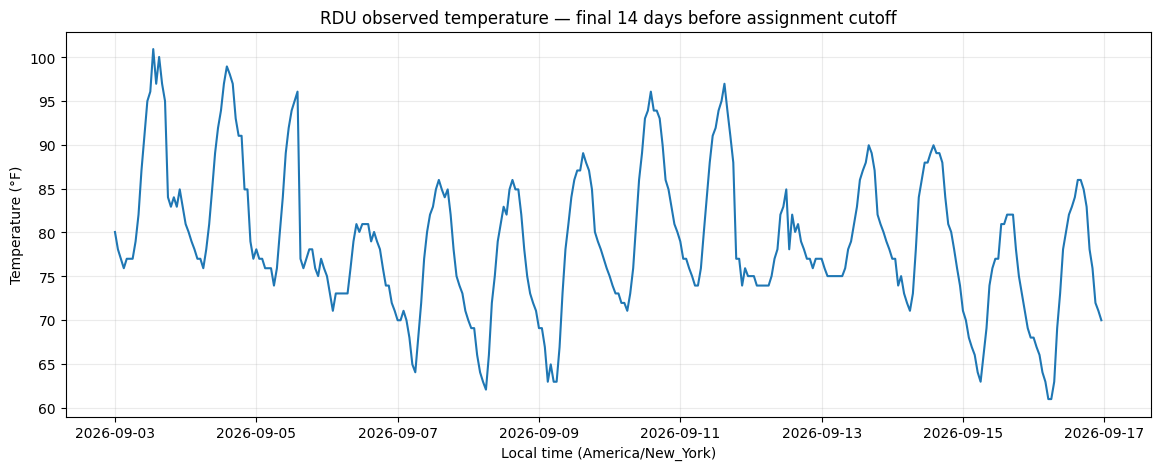

In [12]:
import matplotlib.pyplot as plt

plot_start = CUTOFF_UTC - pd.Timedelta(days=14)

plot_df = out[
    out["hour_utc"] >= plot_start
].copy()

plt.figure(figsize=(14, 5))
plt.plot(
    plot_df["hour_local"],
    plot_df["temperature_f"]
)

plt.title("RDU observed temperature — final 14 days before assignment cutoff")
plt.xlabel("Local time (America/New_York)")
plt.ylabel("Temperature (°F)")
plt.grid(alpha=0.25)
plt.show()

## Reload test

The final cell makes sure the CSV can be loaded cleanly from disk. After this succeeds, `RDU_ACTUAL_HISTORICAL.csv` is ready for our later preprocessing / feature-engineering notebook.

In [13]:
check = pd.read_csv(
    OUTPUT_FILE,
    parse_dates=[
        "observation_time_utc",
        "hour_utc"
    ]
)

print(check.shape)
display(check.head())
display(check.tail())

/tmp/ipykernel_46909/116886383.py:1: DtypeWarning: Columns (19,25) have mixed types. Specify dtype option on import or set low_memory=False.
  check = pd.read_csv(


(93769, 30)


,station_id,station_name,observation_time_utc,hour_utc,observation_time_local,hour_local,temperature_c,temperature_f,dew_point_c,dew_point_f,...,sky_cover_2,sky_cover_3,latitude,longitude,elevation_m,temperature_quality_code,temperature_report_type,temperature_source_code,temperature_source_station_id,source
0,NaN,RALEIGH AP,2016-01-01 05:51:00+00:00,2016-01-01 05:00:00+00:00,2016-01-01 00:51:00-05:00,2016-01-01 00:00:00-05:00,10.0,50.00,6.1,42.98,...,NaN,NaN,35.8922,-78.7819,120.4,5.0,FM15,343.0,723060-13722,NOAA NCEI GHCNh
1,NaN,RALEIGH AP,2016-01-01 06:51:00+00:00,2016-01-01 06:00:00+00:00,2016-01-01 01:51:00-05:00,2016-01-01 01:00:00-05:00,9.4,48.92,5.6,42.08,...,NaN,NaN,35.8922,-78.7819,120.4,5.0,FM15,343.0,723060-13722,NOAA NCEI GHCNh
2,NaN,RALEIGH AP,2016-01-01 07:51:00+00:00,2016-01-01 07:00:00+00:00,2016-01-01 02:51:00-05:00,2016-01-01 02:00:00-05:00,8.9,48.02,4.4,39.92,...,NaN,NaN,35.8922,-78.7819,120.4,5.0,FM15,343.0,723060-13722,NOAA NCEI GHCNh
3,NaN,RALEIGH AP,2016-01-01 08:51:00+00:00,2016-01-01 08:00:00+00:00,2016-01-01 03:51:00-05:00,2016-01-01 03:00:00-05:00,8.3,46.94,3.9,39.02,...,NaN,NaN,35.8922,-78.7819,120.4,5.0,FM15,343.0,723060-13722,NOAA NCEI GHCNh
4,NaN,RALEIGH AP,2016-01-01 09:51:00+00:00,2016-01-01 09:00:00+00:00,2016-01-01 04:51:00-05:00,2016-01-01 04:00:00-05:00,8.3,46.94,3.3,37.94,...,NaN,NaN,35.8922,-78.7819,120.4,5.0,FM15,343.0,723060-13722,NOAA NCEI GHCNh


,station_id,station_name,observation_time_utc,hour_utc,observation_time_local,hour_local,temperature_c,temperature_f,dew_point_c,dew_point_f,...,sky_cover_2,sky_cover_3,latitude,longitude,elevation_m,temperature_quality_code,temperature_report_type,temperature_source_code,temperature_source_station_id,source
93764,NaN,RALEIGH AP,2026-09-16 23:51:00+00:00,2026-09-16 23:00:00+00:00,2026-09-16 19:51:00-04:00,2026-09-16 19:00:00-04:00,25.6,78.08,17.2,62.96,...,NaN,NaN,35.8922,-78.7819,120.4,NaN,FM15,413.0,ICAO-KRDU,NOAA NCEI GHCNh
93765,NaN,RALEIGH AP,2026-09-17 00:51:00+00:00,2026-09-17 00:00:00+00:00,2026-09-16 20:51:00-04:00,2026-09-16 20:00:00-04:00,24.4,75.92,16.7,62.06,...,NaN,NaN,35.8922,-78.7819,120.4,NaN,FM15,413.0,ICAO-KRDU,NOAA NCEI GHCNh
93766,NaN,RALEIGH AP,2026-09-17 01:51:00+00:00,2026-09-17 01:00:00+00:00,2026-09-16 21:51:00-04:00,2026-09-16 21:00:00-04:00,22.2,71.96,16.7,62.06,...,NaN,NaN,35.8922,-78.7819,120.4,NaN,FM15,413.0,ICAO-KRDU,NOAA NCEI GHCNh
93767,NaN,RALEIGH AP,2026-09-17 02:51:00+00:00,2026-09-17 02:00:00+00:00,2026-09-16 22:51:00-04:00,2026-09-16 22:00:00-04:00,21.7,71.06,17.2,62.96,...,NaN,NaN,35.8922,-78.7819,120.4,NaN,FM15,413.0,ICAO-KRDU,NOAA NCEI GHCNh
93768,NaN,RALEIGH AP,2026-09-17 03:51:00+00:00,2026-09-17 03:00:00+00:00,2026-09-16 23:51:00-04:00,2026-09-16 23:00:00-04:00,21.1,69.98,17.2,62.96,...,NaN,NaN,35.8922,-78.7819,120.4,NaN,FM15,413.0,ICAO-KRDU,NOAA NCEI GHCNh
